# The LoRA Assumption That Breaks in Production
LoRA is widely used for fine-tuning large models because it’s efficient, but it quietly assumes that all updates to a model are similar. In reality, they’re not. When you fine-tune for style (like tone, format, or persona), the changes are simple and concentrated in just a few dimensions — which LoRA handles well with low-rank updates. But when you try to teach the model new factual knowledge (like medical data or statistics), the information is spread across many dimensions. A low-rank setup (like rank-8) can’t capture all of it, so the model may sound correct but give wrong or incomplete answers.

Trying to fix this by increasing the rank introduces another problem: instability. As rank increases, the scaling used in standard LoRA causes the learning signal to weaken, making training ineffective. RS-LoRA solves this by slightly adjusting the scaling formula (changing from dividing by r to dividing by √r), which stabilizes learning even at higher ranks. This small change allows the model to better retain complex, high-dimensional information without breaking training.

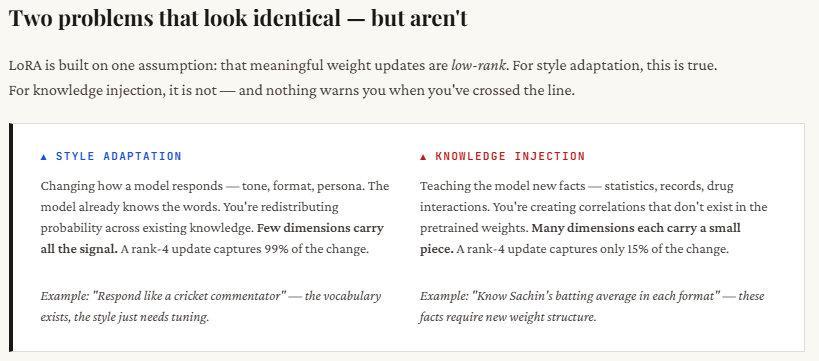

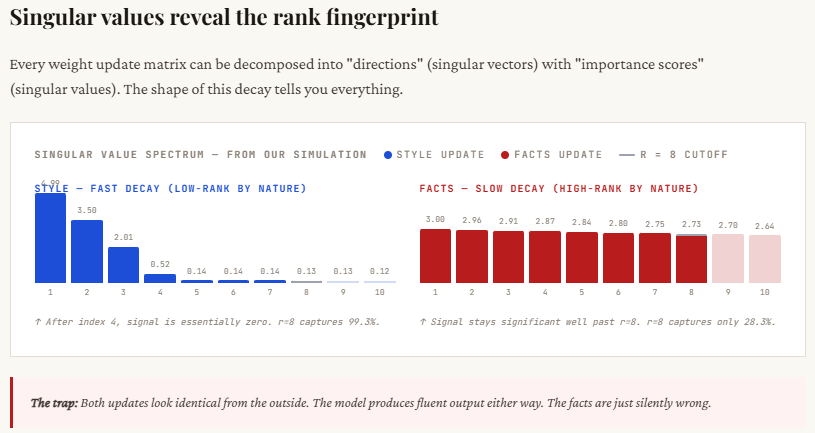

## Setting up the dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)

## The Setup — What are we simulating?
In this setup, we’re simulating how fine-tuning affects a model’s weight matrix by creating a simplified environment. We assume a pre-trained weight matrix of size 64×64 and introduce two types of updates: low-rank “style” changes (like tone or formatting) and high-rank “fact” changes (like detailed cricket statistics). We then define two LoRA configurations — a small rank (r=4), which represents typical LoRA usage, and a larger rank (r=32), which is more suitable for capturing complex information as in RS-LoRA. This allows us to compare how well different ranks can recover these simulated updates and highlight where standard LoRA struggles.

In [2]:
d, k = 64, 64          # weight matrix dimensions
r_low  = 4             # LoRA rank — small (standard choice)
r_high = 32            # LoRA rank — large (RS-LoRA compatible)

print(f"Weight matrix shape : ({d} x {k})")
print(f"Low  rank (standard): r = {r_low}")
print(f"High rank (RS-LoRA) : r = {r_high}")
print(f"Max possible rank   : {min(d, k)}")

Weight matrix shape : (64 x 64)
Low  rank (standard): r = 4
High rank (RS-LoRA) : r = 32
Max possible rank   : 64


## Simulate the "True" Update Matrices
Here, we simulate the two fundamentally different types of fine-tuning updates. The style update is intentionally constructed as low-rank: only a few singular values are large and the rest drop off quickly, meaning most of the important information is concentrated in just a handful of dimensions. This mirrors real-world behavior where tone or formatting changes don’t require widespread modification of the model.

In contrast, the fact update is high-rank: the singular values decay slowly, indicating that many dimensions contribute meaningful information. This reflects how factual knowledge (like statistics or domain data) is distributed across the model. The printed singular values make this clear — style updates show a sharp drop after the first few values, while fact updates remain consistently large across many dimensions, proving they cannot be easily compressed into a low-rank approximation.

In [3]:
def make_low_rank_delta(d, k, true_rank, noise=0.01):
    """Simulates a style update — low intrinsic rank."""
    U = np.random.randn(d, true_rank)
    S = np.linspace(5, 0.5, true_rank)   # fast-decaying singular values
    V = np.random.randn(k, true_rank)
    U, _ = np.linalg.qr(U)
    V, _ = np.linalg.qr(V)
    delta = (U[:, :true_rank] * S) @ V[:, :true_rank].T
    delta += noise * np.random.randn(d, k)
    return delta

def make_high_rank_delta(d, k, noise=0.01):
    """Simulates a fact/knowledge update — high intrinsic rank."""
    U = np.random.randn(d, d)
    S = np.linspace(3, 0.5, min(d, k))   # slow-decaying — many dimensions matter
    V = np.random.randn(k, k)
    U, _ = np.linalg.qr(U)
    V, _ = np.linalg.qr(V)
    delta = (U[:, :min(d,k)] * S) @ V[:, :min(d,k)].T
    delta += noise * np.random.randn(d, k)
    return delta

delta_style = make_low_rank_delta(d, k, true_rank=4)
delta_facts = make_high_rank_delta(d, k)

print("\nStyle  update — top 10 singular values:", np.linalg.svd(delta_style, compute_uv=False)[:10].round(2))
print("Facts  update — top 10 singular values:", np.linalg.svd(delta_facts,  compute_uv=False)[:10].round(2))
print("\nNotice: Style decays fast → low-rank. Facts decay slowly → high-rank.")


Style  update — top 10 singular values: [4.99 3.5  2.01 0.52 0.14 0.14 0.14 0.13 0.13 0.12]
Facts  update — top 10 singular values: [3.   2.96 2.91 2.87 2.84 2.8  2.75 2.73 2.7  2.64]

Notice: Style decays fast → low-rank. Facts decay slowly → high-rank.


## LoRA Approximation (Standard Scaling: alpha/r)
This part compares how well standard LoRA and RS-LoRA can reconstruct the original updates using different ranks. Both methods first use SVD to get the best possible rank-r approximation (i.e., compress the update into r dimensions), but they differ in how they scale the result: standard LoRA divides by r, while RS-LoRA divides by √r. The table shows the reconstruction error — lower means better.

The key takeaway is clear: for style updates, even small ranks (like 4 or 8) work well because the information is naturally low-rank, so the error quickly drops. But for fact updates, the error stays high at low ranks, proving that important information is being lost. Increasing the rank helps, but standard LoRA becomes unstable due to over-scaling (error doesn’t consistently improve). RS-LoRA, with its √r scaling, handles higher ranks more gracefully and reduces error more steadily, making it better suited for capturing complex, high-dimensional knowledge.

In [4]:
def lora_approx_standard(delta, r, alpha=16):
    """Approximate delta using rank-r LoRA with standard alpha/r scaling."""
    U, S, Vt = np.linalg.svd(delta, full_matrices=False)
    # Truncate to rank r
    B = U[:, :r] * S[:r]          # shape (d, r)
    A = Vt[:r, :]                  # shape (r, k)
    scaling = alpha / r
    delta_approx = scaling * (B @ A)
    error = np.linalg.norm(delta - delta_approx, 'fro') / np.linalg.norm(delta, 'fro')
    return delta_approx, error

def lora_approx_rslora(delta, r, alpha=16):
    """Approximate delta using rank-r LoRA with RS-LoRA sqrt(r) scaling."""
    U, S, Vt = np.linalg.svd(delta, full_matrices=False)
    B = U[:, :r] * S[:r]
    A = Vt[:r, :]
    scaling = alpha / np.sqrt(r)   # <-- the key change
    delta_approx = scaling * (B @ A)
    error = np.linalg.norm(delta - delta_approx, 'fro') / np.linalg.norm(delta, 'fro')
    return delta_approx, error

ranks = [2, 4, 8, 16, 32, 48]

style_errors_standard, facts_errors_standard = [], []
style_errors_rslora,   facts_errors_rslora   = [], []

for r in ranks:
    _, e = lora_approx_standard(delta_style, r);  style_errors_standard.append(e)
    _, e = lora_approx_standard(delta_facts, r);  facts_errors_standard.append(e)
    _, e = lora_approx_rslora(delta_style, r);    style_errors_rslora.append(e)
    _, e = lora_approx_rslora(delta_facts, r);    facts_errors_rslora.append(e)

print("Rank | Style Err (std) | Facts Err (std) | Facts Err (RS-LoRA)")
print("-" * 60)
for i, r in enumerate(ranks):
    print(f"  {r:2d} |      {style_errors_standard[i]:.3f}      |      {facts_errors_standard[i]:.3f}      |      {facts_errors_rslora[i]:.3f}")

Rank | Style Err (std) | Facts Err (std) | Facts Err (RS-LoRA)
------------------------------------------------------------
   2 |      6.608      |      2.165      |      3.016
   4 |      2.989      |      1.482      |      2.858
   8 |      1.000      |      1.000      |      2.620
  16 |      0.064      |      0.701      |      2.251
  32 |      0.501      |      0.628      |      1.701
  48 |      0.667      |      0.686      |      1.297


## Scaling Collapse Demo
This section explains why standard LoRA struggles at higher ranks. As the rank r increases, standard LoRA scales the update by α / r, which shrinks rapidly — you can see it drop from 16 (at r=1) to just 0.25 (at r=64). This means that even though you’re adding more dimensions (trying to capture more information), the overall update gets weaker and weaker, effectively suppressing the learning signal. The optimizer then has to compensate by pushing weights harder, which often leads to instability or poor convergence.

RS-LoRA fixes this by changing the scaling to α / √r. Instead of shrinking too aggressively, the scale decreases more gradually — staying strong enough even at higher ranks (e.g., still 2.0 at r=64). This keeps the effective update magnitude meaningful, allowing the model to actually benefit from higher-rank representations without killing the signal. In simple terms: standard LoRA adds capacity but kills its impact, while RS-LoRA preserves both.

In [5]:
alpha = 16
rs = np.arange(1, 65)
standard_scale = alpha / rs
rslora_scale   = alpha / np.sqrt(rs)

print("\nRank | Standard Scale (alpha/r) | RS-LoRA Scale (alpha/sqrt(r))")
print("-" * 55)
for r in [1, 4, 8, 16, 32, 64]:
    print(f"  {r:2d} |         {alpha/r:.4f}          |         {alpha/np.sqrt(r):.4f}")

print("\nStandard scaling vanishes as rank grows.")
print("RS-LoRA scaling stays meaningful at high ranks.")


Rank | Standard Scale (alpha/r) | RS-LoRA Scale (alpha/sqrt(r))
-------------------------------------------------------
   1 |         16.0000          |         16.0000
   4 |         4.0000          |         8.0000
   8 |         2.0000          |         5.6569
  16 |         1.0000          |         4.0000
  32 |         0.5000          |         2.8284
  64 |         0.2500          |         2.0000

Standard scaling vanishes as rank grows.
RS-LoRA scaling stays meaningful at high ranks.


## Singular Value Spectrum
This section shows the core difference in how information is distributed between style and factual updates. For style, most of the important signal is concentrated in just a few dimensions — you can see that with rank 4, over 99% of the information is already captured. This is why low-rank methods like LoRA work so well for tone, format, or persona changes. There’s a clear “elbow” in the singular values — after a few components, the rest don’t matter much.

For facts, it’s the opposite. The information is spread out across many dimensions — even at rank 8, you’re only capturing about 28% of the total signal, which means most of the knowledge is still missing. This is the “long tail” problem: each additional dimension contributes something important. When LoRA truncates to a low rank, it cuts off this tail, leading to incomplete or incorrect knowledge. That’s why the model may sound confident but still get factual details wrong.

In [6]:
sv_style = np.linalg.svd(delta_style, compute_uv=False)
sv_facts  = np.linalg.svd(delta_facts,  compute_uv=False)

print("Cumulative variance captured by top-r components:\n")
print(f"{'Rank':>5} | {'Style (%)':>10} | {'Facts (%)':>10}")
print("-" * 32)
total_style = np.sum(sv_style**2)
total_facts  = np.sum(sv_facts**2)
for r in [2, 4, 8, 16, 32]:
    cs = 100 * np.sum(sv_style[:r]**2) / total_style
    cf = 100 * np.sum(sv_facts[:r]**2)  / total_facts
    print(f"  {r:3d} | {cs:9.1f}% | {cf:9.1f}%")

print("\nWith r=8, style is nearly fully captured.")
print("With r=8, facts are still poorly captured — the tail matters!")

Cumulative variance captured by top-r components:

 Rank |  Style (%) |  Facts (%)
--------------------------------
    2 |      88.9% |       7.7%
    4 |      99.2% |      14.9%
    8 |      99.3% |      28.3%
   16 |      99.6% |      50.8%
   32 |      99.9% |      80.8%

With r=8, style is nearly fully captured.
With r=8, facts are still poorly captured — the tail matters!


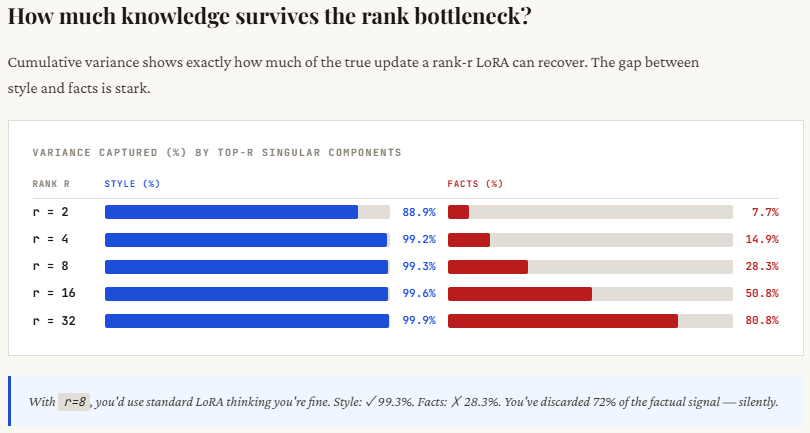

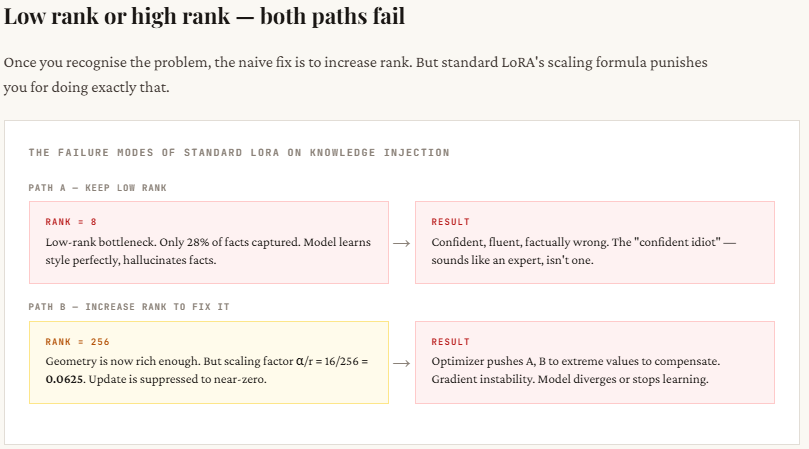

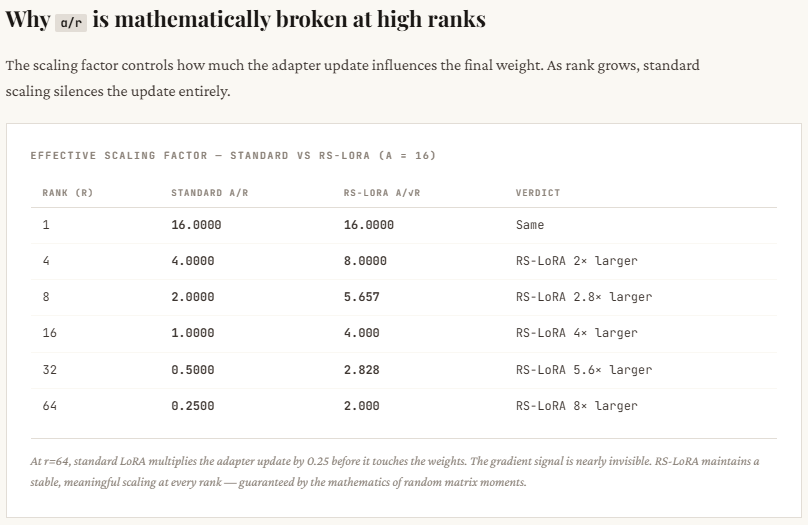

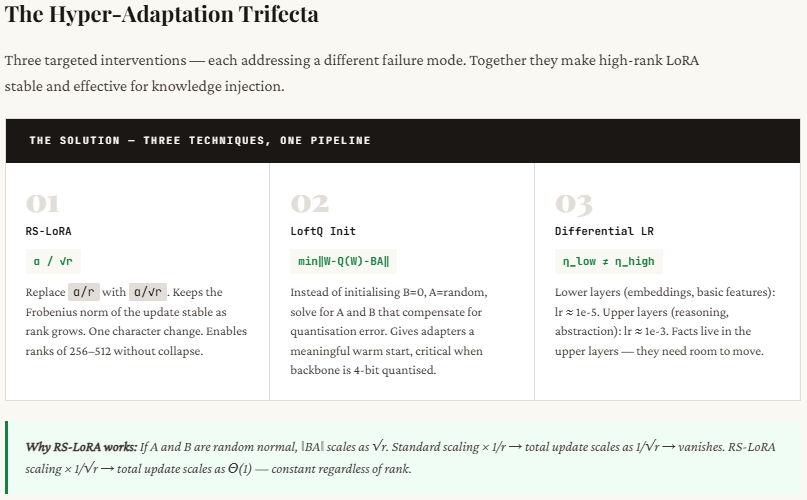

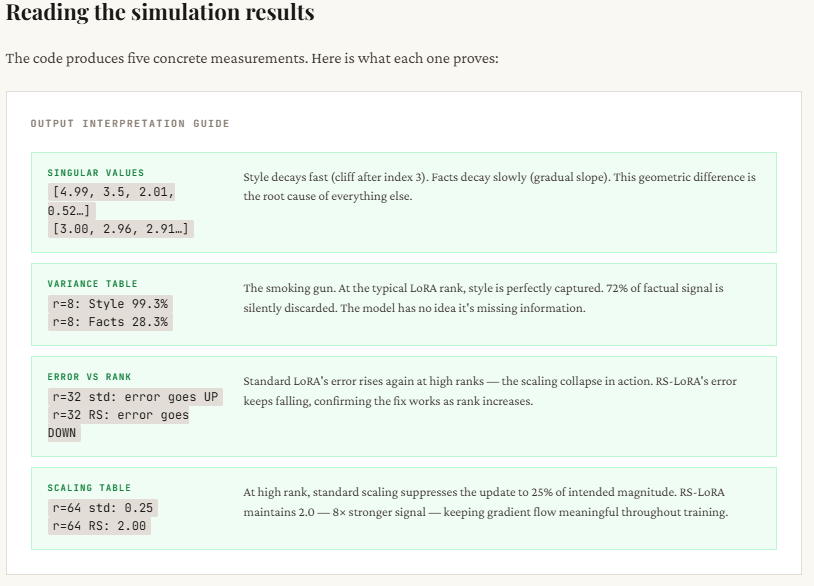